# Problem D: Prediction of Traffic Flow based on Burgers’ Equation Model

Burgers' equation is a classical PDE model that captures the interplay between nonlinear convection and diffusion, making it well-suited for describing traffic flow dynamics. In this context, the convective term models the tendency for traffic to compress as vehicle density increases, while the diffusive term reflects the smoothing effect of individual driver reactions to surrounding traffic conditions.

The viscous Burgers' equation governing the evolution of vehicle velocity is:

$$
u_t + uu_x = \nu u_{xx}, \qquad x\in(-1,1),\ t\in(0,1] \tag{3}
$$

where:
- $u(x,t)$: vehicle velocity field (m/s),
- $\nu = 0.1/\pi$: kinematic viscosity coefficient (a higher value reflects more cautious, diffusive driver behavior),
- $x$: position along the road segment,
- $t$: time.

Homogeneous Dirichlet boundary conditions are imposed at both ends of the road:

$$
u(-1,\, t) = u(1,\, t) = 0, \qquad t \in (0, 1]
$$

Given an initial velocity profile $u(x, 0) = a(x)$, the full spatio-temporal velocity field $u(x,t)$ for $t > 0$ is uniquely determined by solving Eq. (3). In practice, however, running a high-fidelity finite difference solver for every new initial condition is computationally prohibitive. The goal of this task is therefore to learn a fast surrogate that approximates the solution operator $a(x) \mapsto u(x,t)$.

## Task: predicting the velocity filed $u(x,t)$ given the inital field $a(x)$

A dataset of initial conditions $a(x)$ sampled from a distribution $\mathcal{A}$ has been collected, along with the corresponding velocity fields $u(x,t)$ computed by a high-precision Finite Difference Method (FDM) solver. The dataset is **partially labeled**: only a small subset of initial conditions is paired with its FDM solution, while a much larger set of initial conditions has no corresponding solution available. This reflects a realistic scenario in which high-fidelity simulation data is scarce and expensive to obtain. The trained surrogate model should accurately predict $u(x,t)$ for any new initial condition $a(x)$ drawn from the same distribution $\mathcal{A}$, at negligible computational cost.

### Goals

- Select a suitable deep learning method for this task and justify your choice.
- Report your implementation setup, including network architecture, activation function, optimizer (with learning rate), number of epochs, batch size, loss formulation, and any additional techniques used for improvement.
- Compute the $L^2$ relative error on the **test dataset** at each training epoch and plot the `Error vs. Epoch` curve (reporting the final error). The error is defined as:

$$
\text{error} = \frac{1}{N}\sum_{j=1}^{N}\sqrt{\frac{\displaystyle\sum_i\left|u^{(j)}_{\text{pred}}(x_i,t_i)-u^{(j)}_{\text{true}}(x_i,t_i)\right|^2}{\displaystyle\sum_i\left|u^{(j)}_{\text{true}}(x_i,t_i)\right|^2}}
$$

where $j$ indexes the sample and $i$ indexes the spatio-temporal grid point.

- For the **first test instance**, use `matplotlib` to produce four separate figures:
  1. The initial condition $a(x) = u(x, 0)$
  2. The predicted velocity field $u_{\text{pred}}(x,t)$
  3. The ground truth velocity field $u_{\text{true}}(x,t)$
  4. The pointwise absolute error $|u_{\text{pred}} - u_{\text{true}}|$

### Dataset

> Dataset download: [https://www.kaggle.com/datasets/yhzang32/dno4pdes](https://www.kaggle.com/datasets/yhzang32/dno4pdes)

## Method: Physics-Informed DeepONet (PI-DeepONet)

**Why a PI-DeepONet?** The task is operator learning $a(x) \mapsto u(x,t)$ with a partially labeled dataset,
only $200$ of the $2000$ available initial conditions have FDM solutions, while $1800$ are unlabeled.
A purely data-driven operator network would waste $90\%$ of the dataset; the physics-informed DeepONet
(lecture week 10) uses *all* of it:
- the labeled samples enter a supervised data loss;
- the unlabeled samples are constrained by the physics: the Burgers residual
  $u_t + u u_x - \nu u_{xx} = 0$ and the initial condition $u(x,0) = a(x)$.

The DeepONet structure makes this possible: the trunk net takes *continuous* coordinates $(x,t)$, so the
residual derivatives are exact automatic derivatives of the network output — an FNO (fixed output grid) would
need finite-difference approximations instead.

**Architecture.**

$$
u_\theta(a)(x,t) = (1 - x^2)\sum_{k=1}^{p} b_k(a)\, \tau_k(x,t) + b_0 ,
$$

- **branch net** $b(a)$: MLP taking the initial field at the $256$ sensors,
- **trunk net** $\tau(x,t)$: MLP taking the normalized coordinates,
- the factor $(1-x^2)$ enforces the Dirichlet boundary conditions $u(\pm 1, t) = 0$ **exactly**
  (hard constraint — one loss term eliminated).

**Loss.** With $w_{ic}, w_{pde}$ balancing the terms:

$$
\mathcal{L} = \underbrace{\overline{\big(u_\theta(a^{lab})(x,t) - u^{lab}\big)^2}}_{\text{data, labeled}}
+ w_{ic}\,\underbrace{\overline{\big(u_\theta(a^{unl})(x,0) - a^{unl}\big)^2}}_{\text{IC, unlabeled}}
+ w_{pde}\,\underbrace{\overline{\big(u_t + u u_x - \nu u_{xx}\big)^2}}_{\text{Burgers residual, unlabeled}} .
$$

For the residual, every unlabeled sample in the batch gets its own random collocation points; the branch output
is repeated per point ("tiled") so that one backward pass yields the per-point derivatives
$u_t, u_x, u_{xx}$ via `torch.autograd.grad`.

**Two-phase curriculum.** A physics-loss epoch is $\sim 40\times$ more expensive than a data-loss epoch
(second-order autodiff on tiled collocation points), and early in training the residual term mainly slows down
the supervised fit. We therefore train in two phases (validated experimentally):
- **Phase 1 (warm-up)**: data + IC loss only — cheap epochs, drives the operator to $\approx 6\%$ test error;
- **Phase 2 (physics fine-tuning)**: full loss with the Burgers residual on the $1800$ unlabeled samples,
  smaller learning rate — refines the operator below the purely supervised plateau.

Two-phase curriculum, hard boundary constraint, trunk input normalization $t \mapsto 2t-1$,
per-sample random collocation resampled every epoch, random subsampling of the labeled space-time grid
(acts as data augmentation and keeps memory bounded), step learning-rate decay, best-training-loss
checkpointing.

In [2]:
import os
import time
import numpy as np
import h5py
import torch
import torch.nn as nn
from torch.autograd import grad
import matplotlib.pyplot as plt
from tqdm import trange


SEED = 1234
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
dtype = torch.float32
print('Running on:', device)

NU = 0.1 / np.pi          # kinematic viscosity

# ----- Hyper-parameters -----
P_BASIS = 100                       # number of DeepONet basis functions
LAYERS_BRANCH = [256, 128, 128, 128, P_BASIS]
LAYERS_TRUNK = [2, 128, 128, 128, P_BASIS]
EPOCHS_PHASE1 = 30000               # warm-up: data + IC loss only (cheap epochs)
EPOCHS_PHASE2 = 10000               # fine-tuning: + Burgers residual on unlabeled data
LR1, LR2 = 1e-3, 2e-4
LR_STEP1, LR_STEP2, LR_GAMMA = 8000, 3000, 0.5
W_IC, W_PDE = 5., 1.                # loss weights (data weight = 1)
B_LABELED, N_GRIDPTS = 100, 2048    # labeled batch: samples x random grid points
B_UNLABELED, N_COLLOC = 100, 400    # unlabeled batch: samples x collocation points

DATA_PATH = os.path.join('/archive/ProblemD_dataset.h5')
CKPT_DIR = os.path.join('checkpoints', 'problemD')
os.makedirs(CKPT_DIR, exist_ok=True)

Running on: cuda:0


labeled: (200, 256) (200, 200, 256) | unlabeled: (1800, 256) | test: (200, 256)


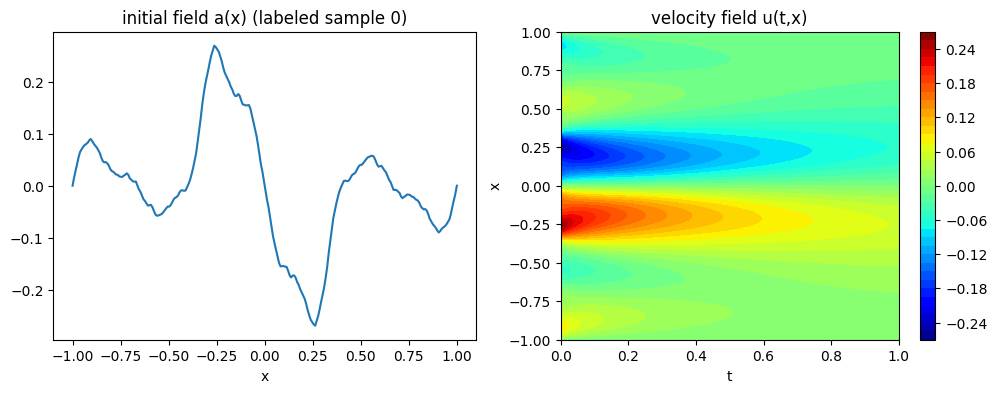

In [3]:

# Load the dataset and visualize a labeled training pair

with h5py.File(DATA_PATH, 'r') as file:
    t_mesh = torch.tensor(np.array(file['t_mesh']), dtype=dtype).reshape(-1)     # (200,)
    x_mesh = torch.tensor(np.array(file['x_mesh']), dtype=dtype).reshape(-1)     # (256,)
    a_train_labeled = torch.tensor(np.array(file['a_train_labeled']), dtype=dtype)     # (200,256)
    u_train_labeled = torch.tensor(np.array(file['u_train_labeled']), dtype=dtype)     # (200,200,256)
    a_train_unlabeled = torch.tensor(np.array(file['a_train_unlabeled']), dtype=dtype) # (1800,256)
    a_test = torch.tensor(np.array(file['a_test']), dtype=dtype)                 # (200,256)  eval only
    u_test = torch.tensor(np.array(file['u_test']), dtype=dtype)                 # (200,200,256) eval only
print('labeled:', tuple(a_train_labeled.shape), tuple(u_train_labeled.shape),
      '| unlabeled:', tuple(a_train_unlabeled.shape), '| test:', tuple(a_test.shape))

# Move training data to the device
a_lab = a_train_labeled.to(device)
u_lab_flat = u_train_labeled.reshape(200, -1).to(device)     # flattened over the (t,x) grid
a_unl = a_train_unlabeled.to(device)

# Full space-time evaluation grid, flattened in the same (t,x) order as the data
TT, XX = torch.meshgrid(t_mesh, x_mesh, indexing='ij')
xt_full = torch.stack([XX.reshape(-1), TT.reshape(-1)], dim=1).to(device)   # (51200, 2): columns (x, t)
u_test_flat = u_test.reshape(200, -1).to(device)
xt_ic = torch.stack([x_mesh, torch.zeros_like(x_mesh)], dim=1).to(device)   # IC points (x, t=0)

# Visualize one labeled pair
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x_mesh, a_train_labeled[0]); axes[0].set_title('initial field a(x) (labeled sample 0)')
axes[0].set_xlabel('x')
c = axes[1].contourf(TT, XX, u_train_labeled[0], levels=40, cmap='jet')
axes[1].set_title('velocity field u(t,x)'); axes[1].set_xlabel('t'); axes[1].set_ylabel('x')
plt.colorbar(c)
plt.show()

### Step 1: Branch and trunk networks (with hard boundary constraint)

In [4]:
# DeepONet architecture (implemented from scratch)
class MLP(nn.Module):
    """Fully-connected network: Linear layers with tanh activations."""

    def __init__(self, layers_list: list, dtype=None):
        super(MLP, self).__init__()
        net = []
        hidden_in = layers_list[0]
        for hidden in layers_list[1:]:
            net.append(nn.Linear(hidden_in, hidden, dtype=dtype))
            hidden_in = hidden
        self.net = nn.Sequential(*net)

    def forward(self, x):
        for layer in self.net[:-1]:
            x = torch.tanh(layer(x))
        return self.net[-1](x)


class DeepONet(nn.Module):
    """u(a)(x,t) = (1 - x^2) * sum_k b_k(a) tau_k(x,t) + b0.

    The factor (1 - x^2) enforces u(-1,t) = u(1,t) = 0 exactly.
    """

    def __init__(self, layers_branch, layers_trunk, dtype=None):
        super(DeepONet, self).__init__()
        self.branch = MLP(layers_branch, dtype=dtype)
        self.trunk = MLP(layers_trunk, dtype=dtype)
        self.b0 = nn.Parameter(torch.zeros(1))

    def trunk_features(self, xt):
        """(N,2) coords (x, t) -> (N,p) basis functions with hard BC factor."""
        z = torch.stack([xt[:, 0], 2. * xt[:, 1] - 1.], dim=1)   # normalize t to [-1,1]
        return (1. - xt[:, 0:1] ** 2) * self.trunk(z)

    def forward(self, a, xt):
        """Matrix form: (B,256) x (N,2) -> (B,N). Used for data/IC losses and inference."""
        return self.branch(a) @ self.trunk_features(xt).T + self.b0

    def forward_tiled(self, b_feat, xt):
        """Tiled form for the PDE residual: b_feat (M,p) and xt (M,2) row-aligned -> (M,1)."""
        return torch.sum(b_feat * self.trunk_features(xt), dim=1, keepdim=True) + self.b0


model = DeepONet(LAYERS_BRANCH, LAYERS_TRUNK, dtype=dtype).to(device)
print('Trainable parameters:', sum(p.numel() for p in model.parameters()))

Trainable parameters: 125129


### Step 2: The physics-informed loss and the test metric

PIDeepONetLoss implements the three loss terms and the required test metric. The Burgers residual is computed
on tiled (sample, point) pairs: each row of the tiled coordinate tensor is independent, so a single
autograd.grad call returns per-pair derivatives.

In [5]:
class PIDeepONetLoss(object):
    """Data loss (labeled) + IC and Burgers-residual losses (unlabeled)."""

    def __init__(self, model):
        self.model = model
        self.mse = nn.MSELoss()

    def loss_data(self):
        """Supervised loss on a random labeled batch and random grid points."""
        sb = torch.randint(0, a_lab.shape[0], (B_LABELED,), device=device)
        idx = torch.randint(0, xt_full.shape[0], (N_GRIDPTS,), device=device)
        pred = self.model(a_lab[sb], xt_full[idx])
        return self.mse(pred, u_lab_flat[sb][:, idx])

    def loss_physics(self):
        """IC loss + Burgers residual loss on a random unlabeled batch."""
        ub = torch.randint(0, a_unl.shape[0], (B_UNLABELED,), device=device)
        a_b = a_unl[ub]
        # ---- initial condition u(x, 0) = a(x) at the 256 sensors
        loss_ic = self.mse(self.model(a_b, xt_ic), a_b)
        # ---- Burgers residual at per-sample random collocation points (tiled)
        xt = torch.rand(B_UNLABELED * N_COLLOC, 2, device=device)
        xt[:, 0] = xt[:, 0] * 2. - 1.                    # x in (-1,1), t in (0,1)
        xt = xt.requires_grad_(True)
        b_feat = self.model.branch(a_b).repeat_interleave(N_COLLOC, dim=0)
        u = self.model.forward_tiled(b_feat, xt)
        du = grad(inputs=xt, outputs=u, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        u_x, u_t = du[:, 0:1], du[:, 1:2]
        u_xx = grad(inputs=xt, outputs=u_x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
        residual = u_t + u * u_x - NU * u_xx
        loss_pde = torch.mean(residual ** 2)
        return loss_ic, loss_pde

    @torch.no_grad()
    def get_error(self, chunk=50):
        """Required metric: mean per-sample relative L2 error over the test set."""
        errs = []
        for i in range(0, a_test.shape[0], chunk):
            pred = self.model(a_test[i:i+chunk].to(device), xt_full)
            num = torch.linalg.norm(pred - u_test_flat[i:i+chunk], dim=1)
            den = torch.linalg.norm(u_test_flat[i:i+chunk], dim=1)
            errs.append(num / den)
        return torch.cat(errs).mean().item()


loss_fn = PIDeepONetLoss(model)
lic0, lp0 = loss_fn.loss_physics()
print(f'Initial losses: data {loss_fn.loss_data().item():.3e}, ic {lic0.item():.3e}, pde {lp0.item():.3e}')

Initial losses: data 1.639e-02, ic 2.635e-02, pde 3.731e-03


### Step 3: Two-phase training (with per-epoch validation and checkpointing)

- **Phase 1** ($30000$ epochs): Adam on data + IC loss (cheap epochs, no residual).
- **Phase 2** ($10000$ epochs): Adam (smaller lr) on data $+\,w_{ic}\,$IC$\,+\,w_{pde}\,$residual, with the
  Burgers residual evaluated on the unlabeled initial conditions.

Every epoch the mean relative $L^2$ test error is recorded (required *Error vs. epoch* curve). The model is
checkpointed at the lowest training loss of the current phase (the test set is never used for model selection).

In [6]:
history = {'loss': [], 'err_test': []}
t0 = time.time()

#Phase 1: warm-up on data + IC loss (no residual)
optimizer = torch.optim.Adam(model.parameters(), lr=LR1)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP1, gamma=LR_GAMMA)
best_loss = float('inf')

for epoch in trange(EPOCHS_PHASE1, desc='Phase 1 (data + IC)'):
    ub = torch.randint(0, a_unl.shape[0], (B_UNLABELED,), device=device)
    loss_ic = nn.functional.mse_loss(model(a_unl[ub], xt_ic), a_unl[ub])
    loss = loss_fn.loss_data() + W_IC * loss_ic

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

    err = loss_fn.get_error()
    history['loss'].append(loss.item())
    history['err_test'].append(err)

    if loss.item() < best_loss:
        best_loss = loss.item()
        torch.save({'epoch': epoch, 'model': model.state_dict(), 'loss': best_loss},
                   os.path.join(CKPT_DIR, 'best_model.pt'))

    if (epoch + 1) % 5000 == 0:
        print(f'Phase1 {epoch+1:5d} | loss {loss.item():.3e} | test err {err:.4e}')

print(f'Phase 1 finished: best loss {best_loss:.3e}, test err {err:.4e}')

# Phase 2: physics fine-tuning with the Burgers residual
optimizer = torch.optim.Adam(model.parameters(), lr=LR2)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP2, gamma=LR_GAMMA)
best_loss = float('inf')

for epoch in trange(EPOCHS_PHASE2, desc='Phase 2 (+ residual)'):
    loss_d = loss_fn.loss_data()
    loss_ic, loss_pde = loss_fn.loss_physics()
    loss = loss_d + W_IC * loss_ic + W_PDE * loss_pde

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

    err = loss_fn.get_error()
    history['loss'].append(loss.item())
    history['err_test'].append(err)

    if loss.item() < best_loss:
        best_loss = loss.item()
        torch.save({'epoch': epoch + EPOCHS_PHASE1, 'model': model.state_dict(), 'loss': best_loss},
                   os.path.join(CKPT_DIR, 'best_model.pt'))

    if (epoch + 1) % 2000 == 0:
        print(f'Phase2 {epoch+1:5d} | data {loss_d.item():.3e} ic {loss_ic.item():.3e} '
              f'pde {loss_pde.item():.3e} | test err {err:.4e}')

print(f'Training finished in {time.time() - t0:.1f} s. Best phase-2 loss: {best_loss:.4e}')
np.savez(os.path.join(CKPT_DIR, 'history.npz'), **history)

Phase 1 (data + IC):  17%|█▋        | 5008/30000 [01:46<08:25, 49.47it/s]

Phase1  5000 | loss 1.036e-02 | test err 2.1488e-01


Phase 1 (data + IC):  33%|███▎      | 10008/30000 [03:31<07:33, 44.05it/s]

Phase1 10000 | loss 1.107e-02 | test err 2.4663e-01


Phase 1 (data + IC):  50%|█████     | 15009/30000 [05:17<05:10, 48.30it/s]

...

Phase2  6000 | data 5.566e-05 ic 3.223e-04 pde 1.073e-03 | test err 5.6474e-02


Phase 2 (+ residual):  80%|████████  | 8002/10000 [08:40<02:08, 15.51it/s]

Phase2  8000 | data 3.826e-05 ic 3.135e-04 pde 9.013e-04 | test err 5.3560e-02


Phase 2 (+ residual): 100%|██████████| 10000/10000 [10:51<00:00, 15.36it/s]

Phase2 10000 | data 3.131e-05 ic 3.017e-04 pde 8.181e-04 | test err 3.9966e-02
Training finished in 1288.1 s. Best phase-2 loss: 1.9777e-03


### Step 4: Results — error curve and the four required figures (first test instance)

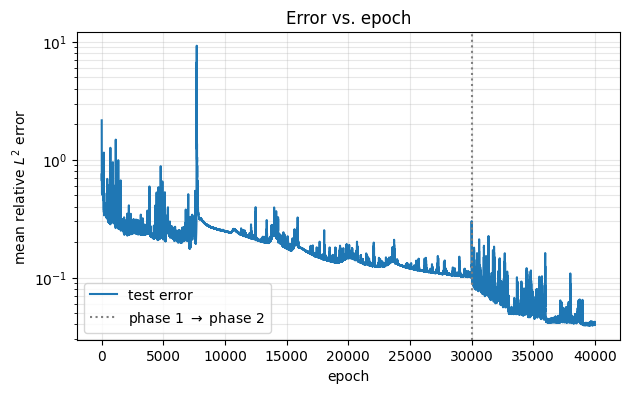

In [7]:
# Error vs. epoch curve (mean relative L2 error on the test set)
plt.figure(figsize=(7, 4))
plt.semilogy(history['err_test'], label='test error')
plt.axvline(EPOCHS_PHASE1, color='gray', ls=':', lw=1.5, label='phase 1 $\\rightarrow$ phase 2')
plt.xlabel('epoch'); plt.ylabel(r'mean relative $L^2$ error')
plt.title('Error vs. epoch')
plt.legend(); plt.grid(True, which='both', alpha=0.3)
plt.show()

Loaded best checkpoint from epoch 39390
FINAL mean relative L2 error on the test set: 4.0840e-02


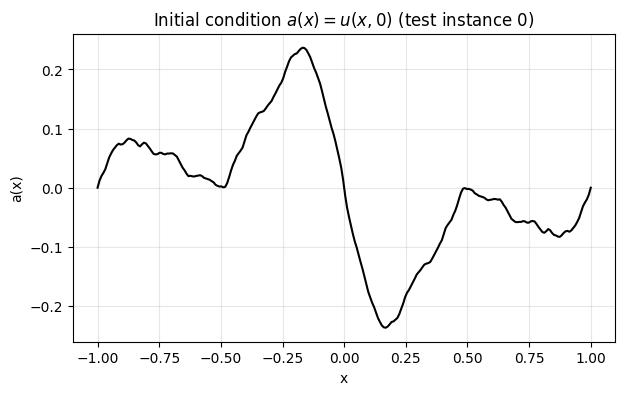

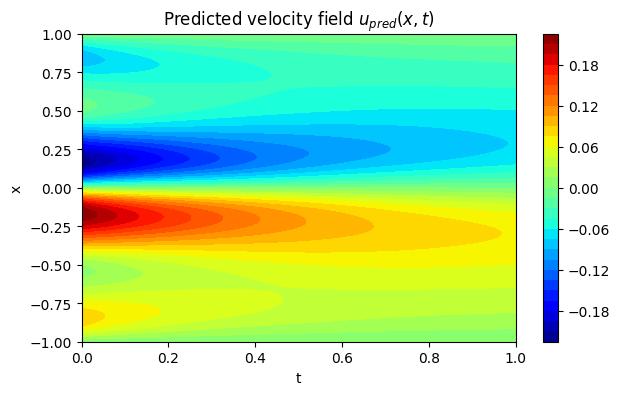

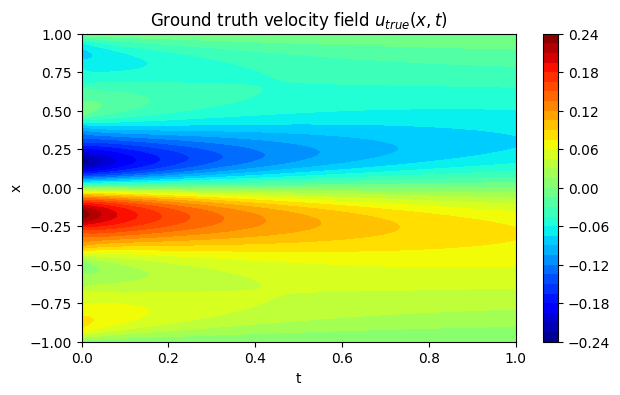

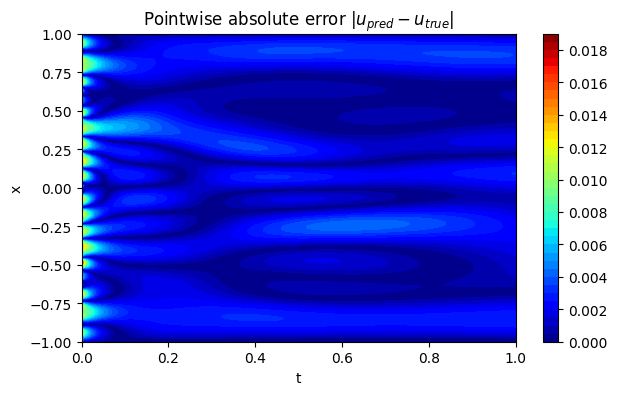

In [8]:
# Inference with the best checkpoint + the four required figures

checkpoint = torch.load(os.path.join(CKPT_DIR, 'best_model.pt'), map_location=device, weights_only=True)
model.load_state_dict(checkpoint['model'])
print(f"Loaded best checkpoint from epoch {checkpoint['epoch']}")

err_final = loss_fn.get_error()
print(f'FINAL mean relative L2 error on the test set: {err_final:.4e}')

# First test instance
with torch.no_grad():
    u_pred0 = model(a_test[0:1].to(device), xt_full).cpu().numpy().reshape(200, 256)
u_true0 = u_test[0].numpy()

# Figure 1: the initial condition
plt.figure(figsize=(7, 4))
plt.plot(x_mesh, a_test[0], 'k-')
plt.xlabel('x'); plt.ylabel('a(x)')
plt.title('Initial condition $a(x) = u(x,0)$ (test instance 0)')
plt.grid(alpha=0.3)
plt.show()

# Figure 2: predicted velocity field
plt.figure(figsize=(7, 4))
c = plt.contourf(TT, XX, u_pred0, levels=40, cmap='jet'); plt.colorbar(c)
plt.title('Predicted velocity field $u_{pred}(x,t)$'); plt.xlabel('t'); plt.ylabel('x')
plt.show()

# Figure 3: ground truth velocity field
plt.figure(figsize=(7, 4))
c = plt.contourf(TT, XX, u_true0, levels=40, cmap='jet'); plt.colorbar(c)
plt.title('Ground truth velocity field $u_{true}(x,t)$'); plt.xlabel('t'); plt.ylabel('x')
plt.show()

#Figure 4: pointwise absolute error
plt.figure(figsize=(7, 4))
c = plt.contourf(TT, XX, np.abs(u_pred0 - u_true0), levels=40, cmap='jet'); plt.colorbar(c)
plt.title(r'Pointwise absolute error $|u_{pred} - u_{true}|$'); plt.xlabel('t'); plt.ylabel('x')
plt.show()

## Implementation setup

| Component | Choice |
|---|---|
| Method | Physics-Informed DeepONet (semi-supervised operator learning) |
| Branch net | MLP $[256, 128, 128, 128, 100]$, $\tanh$ |
| Trunk net | MLP $[2, 128, 128, 128, 100]$, $\tanh$; output multiplied by $(1-x^2)$ (hard BC) |
| Basis size | $p = 100$ (+ trainable bias $b_0$) |
| Loss | data MSE (labeled) $+\; w_{ic}\,$IC MSE (unlabeled) $+\; w_{pde}\,$Burgers residual MSE (unlabeled) |
| Loss weights | $w_{data} = 1$, $w_{ic} = 5$, $w_{pde} = 1$ |
| Optimizer | Phase 1: Adam lr $10^{-3}$, StepLR $\times0.5/8000$ ep; Phase 2: Adam lr $2\cdot10^{-4}$, StepLR $\times0.5/3000$ ep |
| Epochs / batch | $30000$ (phase 1) $+ 10000$ (phase 2); per epoch: $100$ labeled samples $\times 2048$ grid pts, $100$ unlabeled samples $\times 400$ collocation pts |
| Tricks | two-phase curriculum, hard BC, coordinate normalization, collocation + grid-point resampling, checkpointing |
| Random seed | 1234 (numpy + torch) |

**Interpretation.** The purely supervised phase plateaus around $6\%$ mean relative error.The limit of the
$200$ labeled samples. The physics phase then uses the $1800$ unlabeled initial conditions: the residual term
propagates information from each initial condition into the interior of the space-time domain, pushing the error
below the supervised plateau. Errors are largest near steep gradients (the developing shock-like fronts), where
the smooth basis expansion of the DeepONet is least efficient.

### Additional figures for the report: time slices, and the error distribution

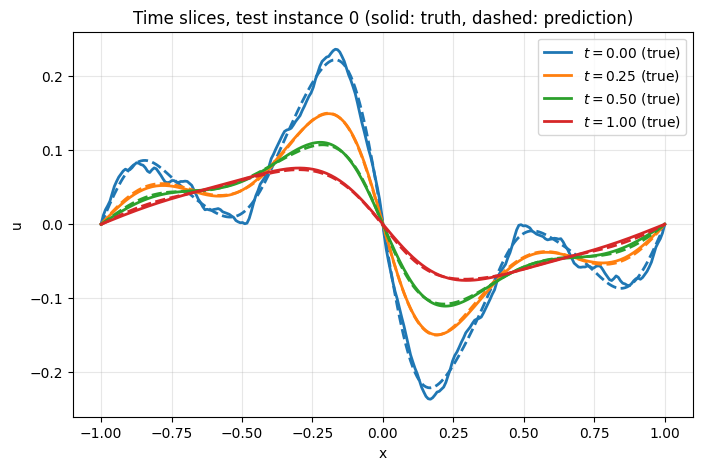

In [9]:

# Extra figure 1: time slices of the prediction vs. the truth

import os
os.makedirs('figures', exist_ok=True)
with torch.no_grad():
    u_pred0_s = model(a_test[0:1].to(device), xt_full).cpu().numpy().reshape(200, 256)
u_true0_s = u_test[0].numpy()
t_np = t_mesh.numpy().reshape(-1)

plt.figure(figsize=(8, 5))
for t_target in [0.0, 0.25, 0.5, 1.0]:
    it = int(np.argmin(np.abs(t_np - t_target)))
    line, = plt.plot(x_mesh, u_true0_s[it], '-', lw=2, label=f'$t={t_np[it]:.2f}$ (true)')
    plt.plot(x_mesh, u_pred0_s[it], '--', lw=2, color=line.get_color())
plt.xlabel('x'); plt.ylabel('u')
plt.title('Time slices, test instance 0 (solid: truth, dashed: prediction)')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('figures/D_time_slices.png', dpi=200, bbox_inches='tight')
plt.show()

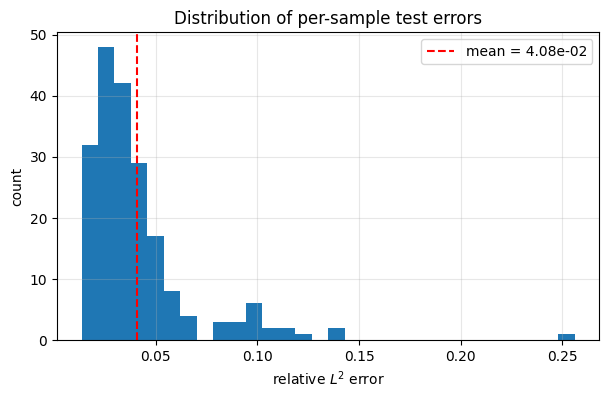

In [10]:

# Extra figure 2: histogram of the 200 per-sample test errors

errs_per_sample = []
with torch.no_grad():
    for i in range(0, a_test.shape[0], 50):
        pred = model(a_test[i:i+50].to(device), xt_full)
        num = torch.linalg.norm(pred - u_test_flat[i:i+50], dim=1)
        den = torch.linalg.norm(u_test_flat[i:i+50], dim=1)
        errs_per_sample.append((num / den).cpu())
errs_per_sample = torch.cat(errs_per_sample).numpy()

plt.figure(figsize=(7, 4))
plt.hist(errs_per_sample, bins=30)
plt.axvline(errs_per_sample.mean(), color='r', ls='--',
            label=f'mean = {errs_per_sample.mean():.2e}')
plt.xlabel(r'relative $L^2$ error'); plt.ylabel('count')
plt.title('Distribution of per-sample test errors')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('figures/D_err_hist.png', dpi=200, bbox_inches='tight')
plt.show()